# Session 2 — quick EDA (scratch notebook)

Exploration that replaces the Session 2 homework: metadata vs. target, colour per class, class balance.
Plots are saved to `outputs/figures/` and the findings at the bottom are reused in B2.

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from src import config
from src.data import load_metadata, load_gt, add_labels, image_path
from src.viz import plot_class_balance, show_grid

config.FIG_DIR.mkdir(parents=True, exist_ok=True)
meta = add_labels(load_metadata(), load_gt())
lesions = meta.drop_duplicates("lesion_id")
print(meta.shape, lesions.shape)

(10480, 18) (5240, 18)


## Class balance (per lesion)

diagnosis_1
Malignant        0.694
Benign           0.283
Indeterminate    0.023
Name: proportion, dtype: float64

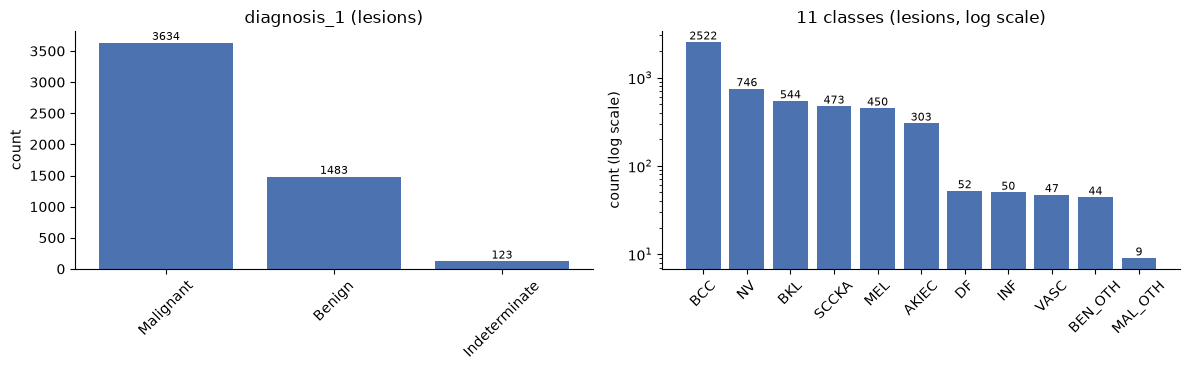

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
plot_class_balance(lesions.diagnosis_1, ax=axes[0], title="diagnosis_1 (lesions)")
plot_class_balance(lesions.dx, log=True, ax=axes[1], title="11 classes (lesions, log scale)")
fig.savefig(config.FIG_DIR / "s2_class_balance.png", dpi=120, bbox_inches="tight")
lesions.diagnosis_1.value_counts(normalize=True).round(3)

## Metadata vs. target: age, sex, site

                count  mean   std   min   25%   50%   75%   max
diagnosis_1                                                    
Benign         1463.0  51.6  18.8   5.0  40.0  55.0  65.0  85.0
Indeterminate   123.0  67.8  10.9  35.0  60.0  70.0  75.0  85.0
Malignant      3634.0  65.1  12.4  20.0  55.0  65.0  75.0  85.0


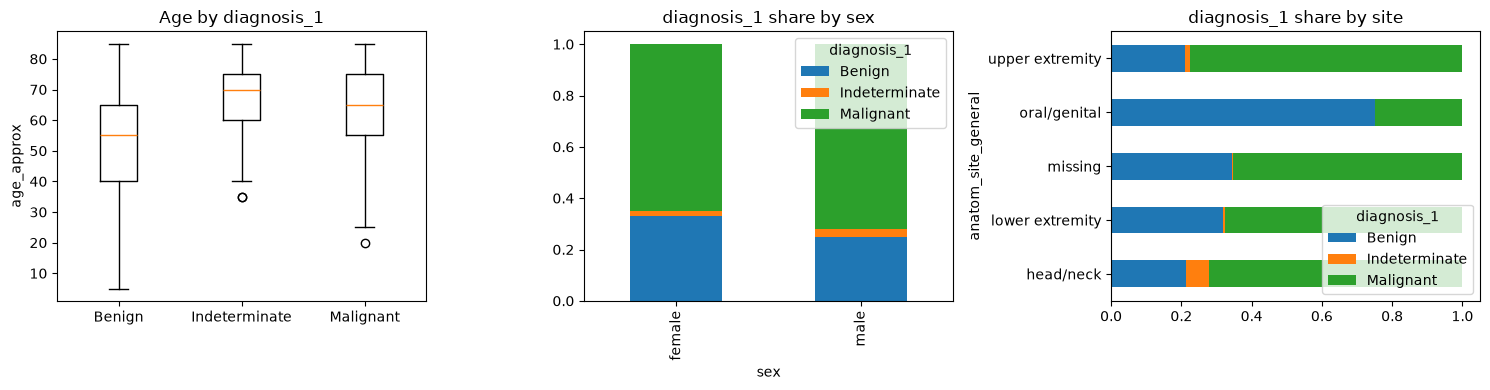

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
order = config.DX1_CLASSES
axes[0].boxplot([lesions.loc[lesions.diagnosis_1 == c, "age_approx"].dropna() for c in order])
axes[0].set_xticks(range(1, 4), order)
axes[0].set_title("Age by diagnosis_1"); axes[0].set_ylabel("age_approx")
pd.crosstab(lesions.sex, lesions.diagnosis_1, normalize="index").plot.bar(stacked=True, ax=axes[1])
axes[1].set_title("diagnosis_1 share by sex")
pd.crosstab(lesions.anatom_site_general.fillna("missing"), lesions.diagnosis_1, normalize="index").plot.barh(stacked=True, ax=axes[2])
axes[2].set_title("diagnosis_1 share by site")
fig.tight_layout()
fig.savefig(config.FIG_DIR / "s2_metadata_vs_target.png", dpi=120, bbox_inches="tight")
print(lesions.groupby("diagnosis_1").age_approx.describe().round(1))

In [4]:
lesions.groupby("dx").age_approx.median().sort_values()

dx
NV         40.0
DF         50.0
VASC       55.0
BEN_OTH    60.0
INF        60.0
BCC        65.0
BKL        65.0
AKIEC      65.0
MEL        65.0
SCCKA      70.0
MAL_OTH    75.0
Name: age_approx, dtype: float64

## Colour per class (sample of 60 dermoscopic images per diagnosis_1 class)

,R,G,B
Benign,170.6,144.5,145.5
Indeterminate,165.2,127.3,128.0
Malignant,166.3,137.0,137.7


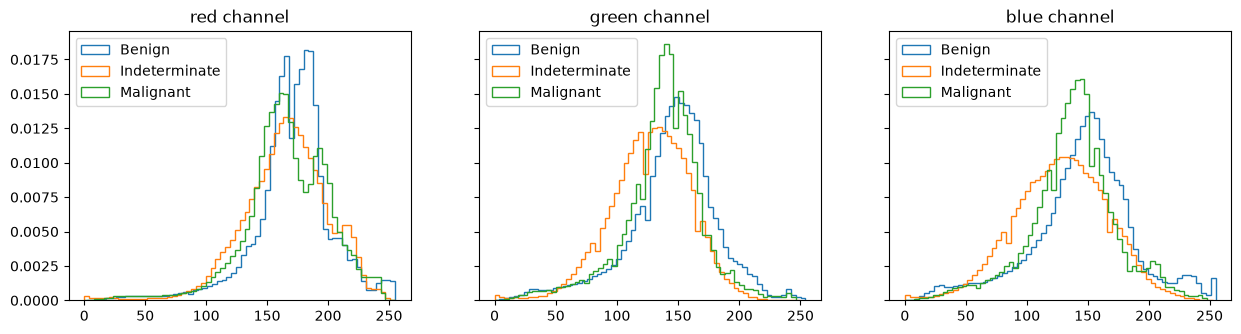

In [5]:
rng = np.random.default_rng(config.SEED)
derm = meta[meta.image_type == config.DERM]
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5), sharey=True)
mean_rgb = {}
for c in order:
    ids = derm[derm.diagnosis_1 == c].isic_id.sample(60, random_state=config.SEED)
    px = np.concatenate([np.asarray(Image.open(image_path(i)).convert("RGB").resize((128, 128))).reshape(-1, 3) for i in ids])
    mean_rgb[c] = px.mean(axis=0).round(1)
    for k, col in enumerate("rgb"):
        axes[k].hist(px[:, k], bins=64, histtype="step", density=True, label=c)
for k, col in enumerate(["red", "green", "blue"]):
    axes[k].set_title(f"{col} channel"); axes[k].legend()
fig.savefig(config.FIG_DIR / "s2_colour_histograms.png", dpi=120, bbox_inches="tight")
pd.DataFrame(mean_rgb, index=["R", "G", "B"]).T

## A few examples

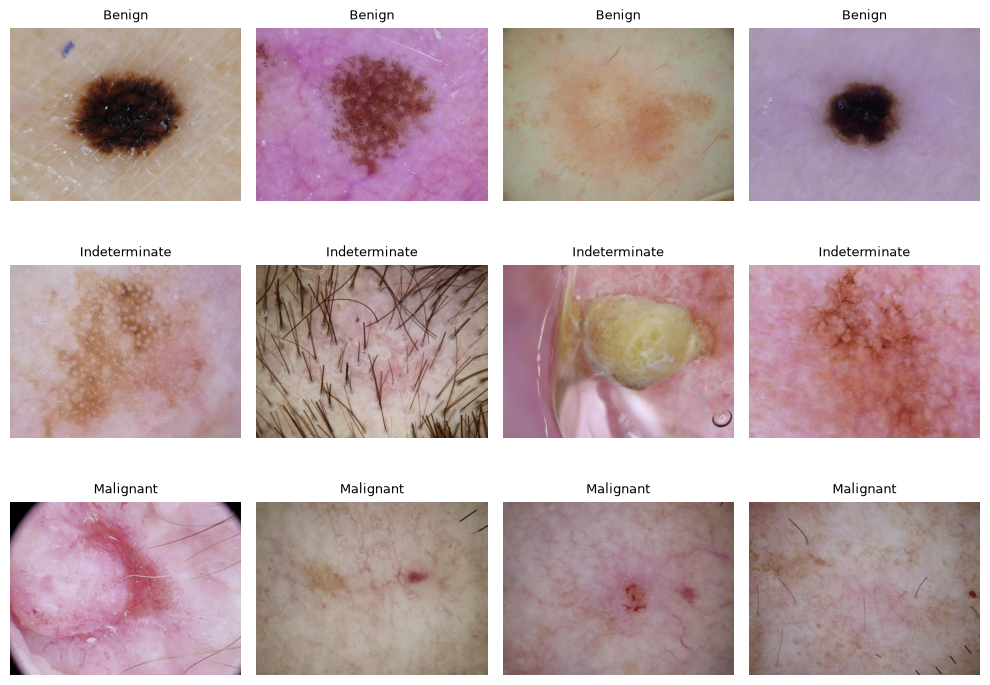

In [6]:
ex = derm.groupby("diagnosis_1").sample(4, random_state=config.SEED)
fig = show_grid([Image.open(image_path(i)) for i in ex.isic_id], ex.diagnosis_1.tolist(), ncols=4)

## Findings (used in B2)

1. **Class balance:** the data are dominated by Malignant lesions (69 % of lesions); BCC alone is 48 % of all lesions, Indeterminate is only 2.3 %, and MAL_OTH has just 9 lesions.
2. **Age:** malignant and indeterminate lesions come from older patients (median 65 and 70 years) than benign ones (median 55); NV has the youngest patients (median 40).
3. **Site:** `anatom_site_general` is missing for 37 % of lesions. Indeterminate lesions are concentrated on the head/neck (6.6 % there vs < 1.5 % elsewhere), and lesions with a missing site are more often NV/benign.
4. **Sex:** male patients have a higher malignant share (72 %) than female patients (65 %).
5. **Colour:** mean RGB differs slightly by class (benign images are a little brighter and less red than malignant/indeterminate ones), so colour carries some diagnostic signal and colour augmentation must stay mild.